# Sentiment Analysis using DeBerta

---
# Module_1A_EDA


# Sentiment Analysis using DeBerta

## Module 1A: Exploratory Data Analysis (EDA)

This notebook performs basic EDA on `reviews.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
reviews = pd.read_csv("reviews.csv")
print("Datasets Loaded Successfully")

Datasets Loaded Successfully


## Dataset Overview

In [3]:
def dataset_overview(df, dataset_name):
    print("="*80)
    print(dataset_name)
    print("="*80)
    print("\nShape")
    print(df.shape)
    print("\nColumns")
    print(df.columns.tolist())
    print("\nFirst Five Rows")
    display(df.head())
    print("\nLast Five Rows")
    display(df.tail())
    print("\nRandom Sample")
    display(df.sample(5))
    print("\nDataset Information")
    df.info()
    print("\nStatistical Summary")
    display(df.describe(include="all"))

dataset_overview(reviews,"Reviews Dataset")

Reviews Dataset

Shape
(107018, 3)

Columns
['Id', 'Review', 'Label']

First Five Rows


,Id,Review,Label
0,0,good and interesting,5
1,1,"This class is very helpful to me. Currently, I...",5
2,2,like!Prof and TAs are helpful and the discussi...,5
3,3,Easy to follow and includes a lot basic and im...,5
4,4,Really nice teacher!I could got the point eazl...,4



Last Five Rows


,Id,Review,Label
107013,107013,Trendy topic with talks from expertises in the...,4
107014,107014,"Wonderful! Simple and clear language, good ins...",5
107015,107015,an interesting and fun course. thanks. dr quincy,5
107016,107016,"very broad perspective, up to date information...",4
107017,107017,An informative course on the social and financ...,4



Random Sample


,Id,Review,Label
783,783,An easy to understand and very resourceful cou...,5
41284,41284,For someone who is not familiar with inferenti...,1
18738,18738,"Great course, well-constructed and very inform...",4
12169,12169,"Like it, very interesting and useful !!! Thank...",5
17441,17441,Great course that caused me to get out of my c...,5



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107018 entries, 0 to 107017
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Id      107018 non-null  int64 
 1   Review  107018 non-null  object
 2   Label   107018 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.4+ MB

Statistical Summary


,Id,Review,Label
count,107018.000000,107018,107018.000000
unique,NaN,100038,NaN
top,NaN,Great course!,NaN
freq,NaN,509,NaN
mean,53508.500000,NaN,4.581145
std,30893.579891,NaN,0.860956
min,0.000000,NaN,1.000000
25%,26754.250000,NaN,4.000000
50%,53508.500000,NaN,5.000000
75%,80262.750000,NaN,5.000000


## Missing Value Analysis

,Column,Missing Values,Percentage
0,Id,0,0.0
1,Review,0,0.0
2,Label,0,0.0


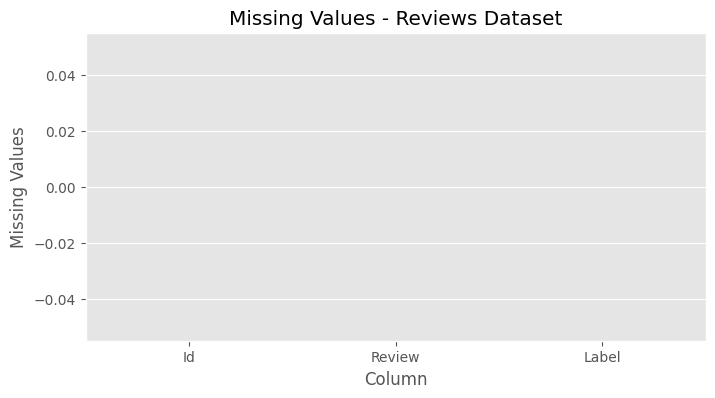

In [4]:
def missing_values(df,name):
    missing=df.isnull().sum()
    report=pd.DataFrame({
        "Column":missing.index,
        "Missing Values":missing.values,
        "Percentage":((missing/len(df))*100).round(2).values
    })
    display(report)
    plt.figure(figsize=(8,4))
    sns.barplot(data=report,x="Column",y="Missing Values")
    plt.title(f"Missing Values - {name}")
    plt.show()

missing_values(reviews,"Reviews Dataset")

## Duplicate Analysis

In [5]:
def duplicate_analysis(df,name):
    print("="*70)
    print(name)
    print("="*70)
    print("Duplicate Rows:",df.duplicated().sum())
    print("Duplicate Reviews:",df.duplicated(subset=["Review"]).sum())

duplicate_analysis(reviews,"Reviews Dataset")

Reviews Dataset
Duplicate Rows: 0
Duplicate Reviews: 6980


## Label Distribution

,Count,Percentage
Label,,
1,2469,2.31
2,2251,2.10
3,5071,4.74
4,18054,16.87
5,79173,73.98


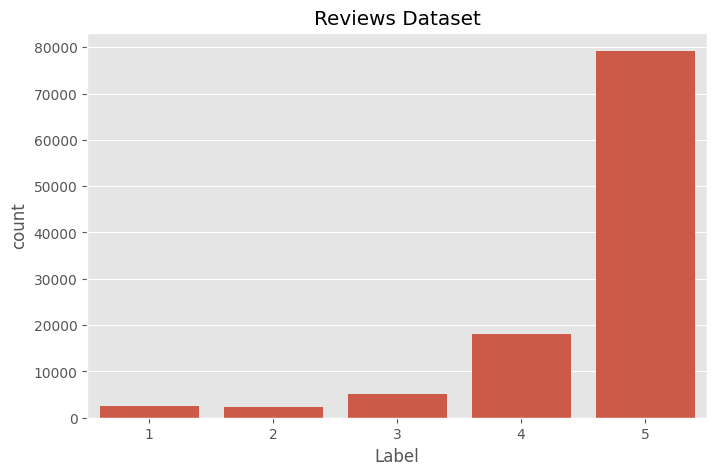

In [6]:
def label_distribution(df,name):
    summary=pd.DataFrame({
        "Count":df["Label"].value_counts().sort_index(),
        "Percentage":(df["Label"].value_counts(normalize=True).sort_index()*100).round(2)
    })
    display(summary)
    plt.figure(figsize=(8,5))
    sns.countplot(data=df,x="Label")
    plt.title(name)
    plt.show()

label_distribution(reviews,"Reviews Dataset")

## Review Length Analysis

,Review Length
count,107018.000000
mean,146.798978
std,188.874884
min,1.000000
25%,44.000000
50%,90.000000
75%,180.000000
max,7766.000000


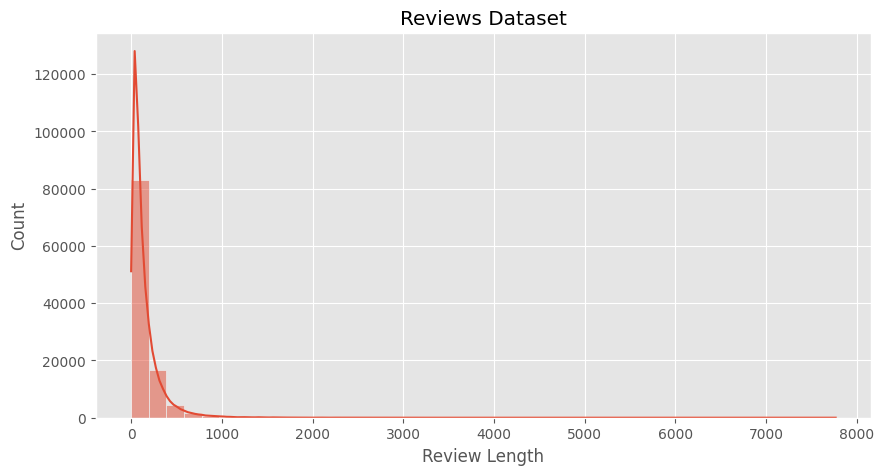

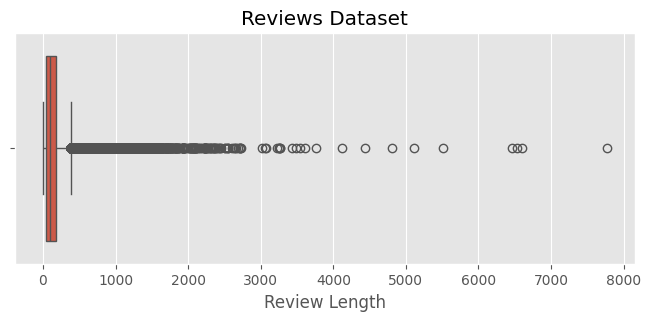

In [7]:
def review_length(df,name):
    df["Review Length"]=df["Review"].astype(str).apply(len)
    display(df["Review Length"].describe())
    plt.figure(figsize=(10,5))
    sns.histplot(df["Review Length"],bins=40,kde=True)
    plt.title(name)
    plt.show()
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df["Review Length"])
    plt.title(name)
    plt.show()

review_length(reviews,"Reviews Dataset")

## Word Count Analysis

,Word Count
count,107018.000000
mean,24.871134
std,32.427376
min,1.000000
25%,7.000000
50%,15.000000
75%,31.000000
max,1338.000000


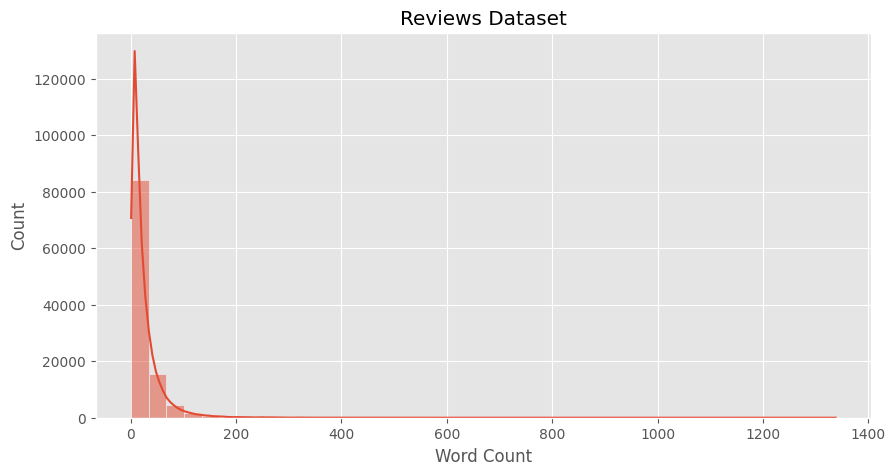

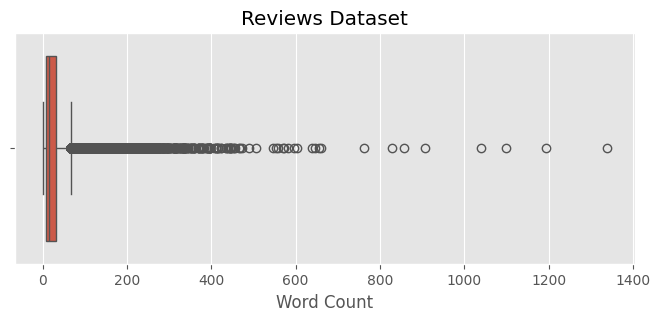

In [8]:
def word_count(df,name):
    df["Word Count"]=df["Review"].astype(str).apply(lambda x: len(x.split()))
    display(df["Word Count"].describe())
    plt.figure(figsize=(10,5))
    sns.histplot(df["Word Count"],bins=40,kde=True)
    plt.title(name)
    plt.show()
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df["Word Count"])
    plt.title(name)
    plt.show()

word_count(reviews,"Reviews Dataset")

## Dataset Summary

In [9]:
def dataset_summary(df,name):
    print("="*80)
    print(name)
    print("="*80)
    print("Total Reviews:",len(df))
    print("Missing Reviews:",df["Review"].isnull().sum())
    print("Duplicate Reviews:",df.duplicated(subset=["Review"]).sum())
    print("Average Review Length:",round(df["Review Length"].mean(),2))
    print("Average Word Count:",round(df["Word Count"].mean(),2))

dataset_summary(reviews,"Reviews Dataset")

Reviews Dataset
Total Reviews: 107018
Missing Reviews: 0
Duplicate Reviews: 6980
Average Review Length: 146.8
Average Word Count: 24.87


---
# Module_1B_Advanced_EDA


# Module 1B: Advanced Exploratory Data Analysis (EDA)

This notebook performs advanced NLP-oriented EDA on both datasets.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import re
import warnings
warnings.filterwarnings("ignore")

reviews=pd.read_csv("reviews.csv")


## Word Cloud

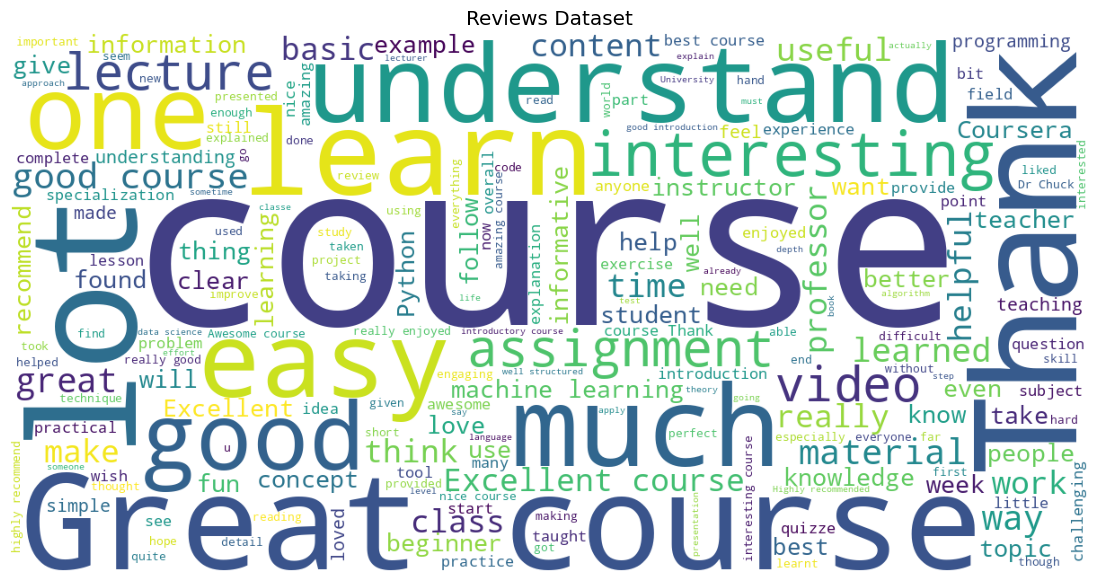

In [11]:
def plot_wordcloud(df,title):
    text=" ".join(df["Review"].fillna("").astype(str))
    wc=WordCloud(width=1200,height=600,background_color="white").generate(text)
    plt.figure(figsize=(14,7))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_wordcloud(reviews,"Reviews Dataset")

## Top 20 Words

,Word,Count
0,the,130856
1,and,91883
2,to,86128
3,course,84641
4,i,71271
5,a,65794
6,of,55335
7,this,44184
8,is,42724
9,it,42654


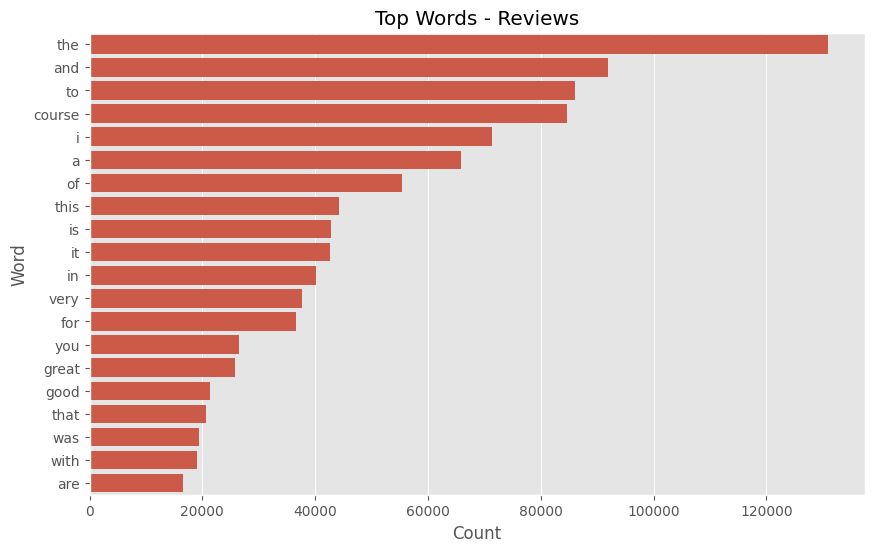

In [12]:
def top_words(df,title):
    words=re.findall(r"\b\w+\b"," ".join(df["Review"].fillna("").astype(str)).lower())
    common=Counter(words).most_common(20)
    top=pd.DataFrame(common,columns=["Word","Count"])
    display(top)
    plt.figure(figsize=(10,6))
    sns.barplot(data=top,x="Count",y="Word")
    plt.title(title)
    plt.show()

top_words(reviews,"Top Words - Reviews")


## Top 20 Bigrams

,Bigram,Count
201962,great course,9416
196710,good course,4987
155367,excellent course,3920
291099,machine learning,3522
266661,learned lot,2246
97387,course really,1988
135999,easy understand,1986
95499,course great,1848
392032,recommend course,1825
95464,course good,1472


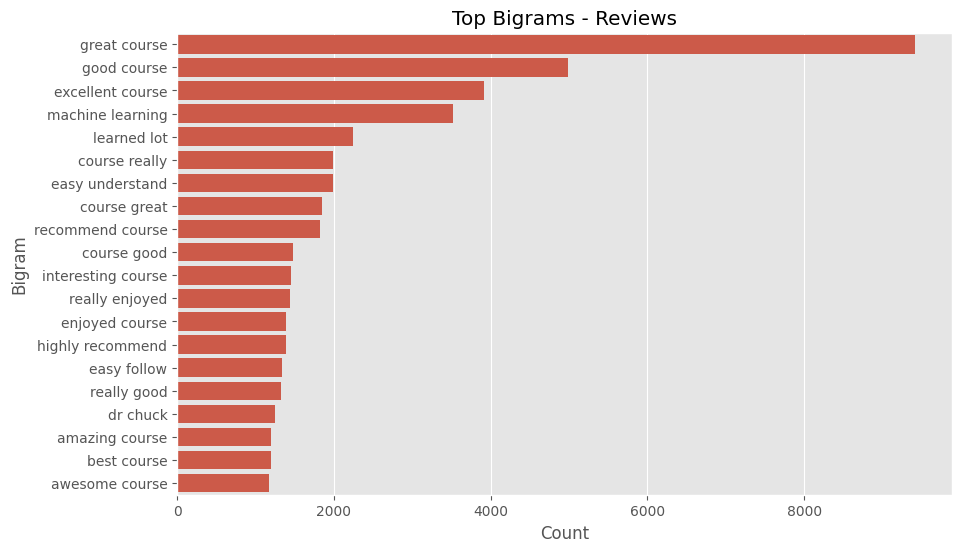

In [13]:
def top_bigrams(df,title):
    vec=CountVectorizer(ngram_range=(2,2),stop_words="english")
    X=vec.fit_transform(df["Review"].fillna("").astype(str))
    counts=X.sum(axis=0).A1
    vocab=vec.get_feature_names_out()
    big=pd.DataFrame({"Bigram":vocab,"Count":counts}).sort_values("Count",ascending=False).head(20)
    display(big)
    plt.figure(figsize=(10,6))
    sns.barplot(data=big,x="Count",y="Bigram")
    plt.title(title)
    plt.show()

top_bigrams(reviews,"Top Bigrams - Reviews")


## Top 20 Trigrams

,Trigram,Count
693511,really enjoyed course,600
395618,highly recommend course,516
167313,course learned lot,475
694455,really good course,372
365908,great course great,368
445434,introduction machine learning,320
482442,learned lot course,297
353856,good introductory course,286
169603,course machine learning,271
369687,great introductory course,252


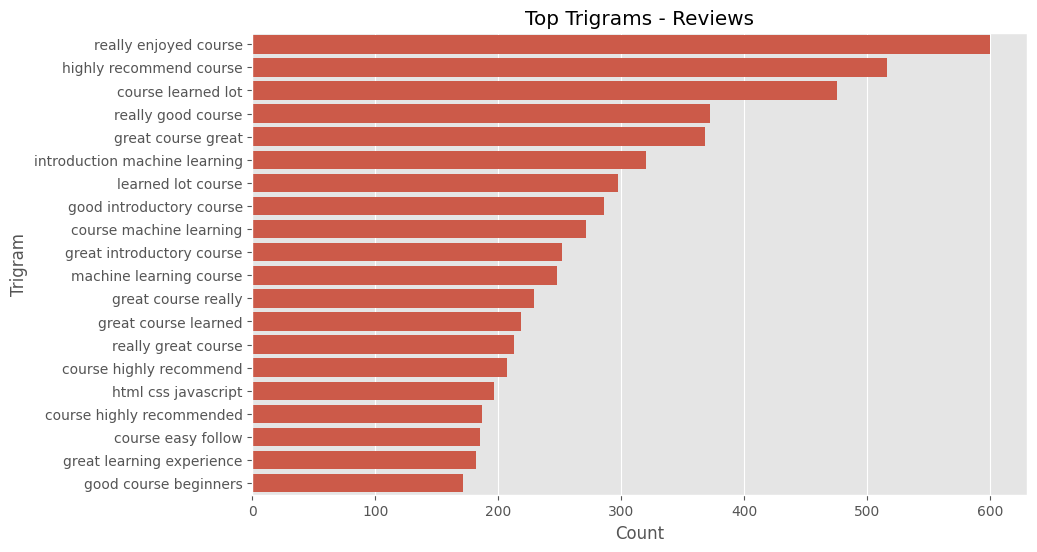

In [14]:
def top_trigrams(df,title):
    vec=CountVectorizer(ngram_range=(3,3),stop_words="english")
    X=vec.fit_transform(df["Review"].fillna("").astype(str))
    counts=X.sum(axis=0).A1
    vocab=vec.get_feature_names_out()
    tri=pd.DataFrame({"Trigram":vocab,"Count":counts}).sort_values("Count",ascending=False).head(20)
    display(tri)
    plt.figure(figsize=(10,6))
    sns.barplot(data=tri,x="Count",y="Trigram")
    plt.title(title)
    plt.show()

top_trigrams(reviews,"Top Trigrams - Reviews")


## Review Length vs Rating

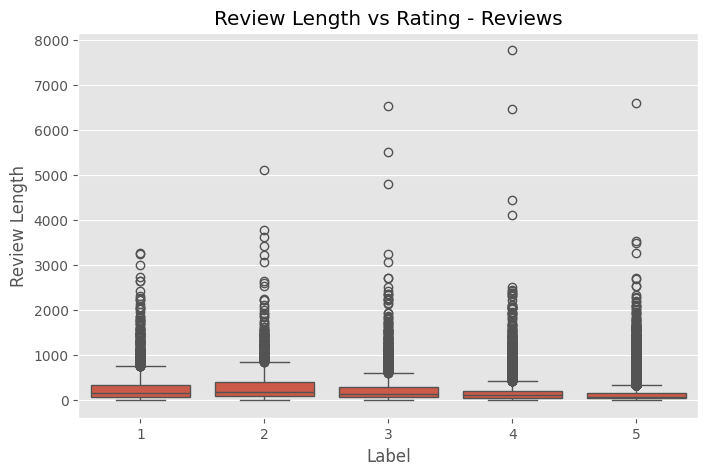

In [15]:
for df,name in [(reviews,"Reviews")]:
    df["Review Length"]=df["Review"].fillna("").astype(str).apply(len)
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df,x="Label",y="Review Length")
    plt.title(f"Review Length vs Rating - {name}")
    plt.show()


## Export EDA Report

In [16]:
def eda_report(df,name):
    report=pd.DataFrame({
        "Metric":[
            "Rows","Columns","Missing Reviews","Duplicate Reviews","Average Review Length"
        ],
        "Value":[
            len(df),
            len(df.columns),
            df["Review"].isnull().sum(),
            df.duplicated(subset=["Review"]).sum(),
            df["Review"].fillna("").astype(str).apply(len).mean()
        ]
    })
    report.to_csv(f"{name}_EDA_Report.csv",index=False)
    display(report)

eda_report(reviews,"Reviews")
print("EDA reports saved.")


,Metric,Value
0,Rows,107018.000000
1,Columns,4.000000
2,Missing Reviews,0.000000
3,Duplicate Reviews,6980.000000
4,Average Review Length,146.798978


EDA reports saved.


---
# Module_2_Preprocessing


# Module 2: Data Preprocessing

This notebook cleans both datasets and prepares them for DeBerta.

In [17]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

reviews=pd.read_csv("reviews.csv")
print("Datasets Loaded")

Datasets Loaded


## Save Original Statistics

In [18]:
def dataset_statistics(df):
    return {
        "Total Rows":len(df),
        "Missing Reviews":df["Review"].isnull().sum(),
        "Duplicate Reviews":df.duplicated(subset=["Review"]).sum(),
        "Empty Reviews":(df["Review"].fillna("").str.strip()=="").sum()
    }

reviews_before=dataset_statistics(reviews)

## Text Cleaning Function

In [19]:
def clean_text(text):

    if pd.isna(text):
        return ""

    text=str(text)

    text=re.sub(r"<.*?>"," ",text)
    text=re.sub(r"http\S+|www\S+"," ",text)
    text=re.sub(r"\S+@\S+"," ",text)
    text=re.sub(r"\s+"," ",text)

    return text.strip()


## Apply Preprocessing

In [20]:
def preprocess(df):

    df = df.copy()

    # Clean text
    df["Review"] = df["Review"].apply(clean_text)

    # Remove empty reviews
    df = df[df["Review"].str.strip() != ""]

    # Remove reviews with less than 2 words
    df = df[df["Review"].apply(lambda x: len(str(x).split()) >= 2)]

    # Remove duplicate reviews
    df = df.drop_duplicates(subset=["Review"])

    # Remove missing values
    df = df.dropna(subset=["Review"])

    # Ensure string datatype
    df["Review"] = df["Review"].astype(str)

    # Convert ratings to sentiment labels
    df["Label"] = df["Label"].apply(
        lambda x: 0 if x in [1, 2]
        else 1 if x == 3
        else 2
    )

    df.reset_index(drop=True, inplace=True)

    return df


reviews_clean = preprocess(reviews)

print("Preprocessing Completed")

Preprocessing Completed


## Save Cleaned Datasets

In [21]:
reviews_clean.to_csv("reviews_cleaned.csv",index=False)

print("Cleaned datasets saved.")

Cleaned datasets saved.


In [22]:
print("Label Distribution")
print(reviews_clean["Label"].value_counts().sort_index())

print("\nMeaning:")
print("0 = Negative (Ratings 1 & 2)")
print("1 = Neutral (Rating 3)")
print("2 = Positive (Ratings 4 & 5)")

Label Distribution
Label
0     4596
1     4978
2    90276
Name: count, dtype: int64

Meaning:
0 = Negative (Ratings 1 & 2)
1 = Neutral (Rating 3)
2 = Positive (Ratings 4 & 5)


## Preprocessing Report

In [23]:
reviews_after=dataset_statistics(reviews_clean)

def report(before,after,title):

    df=pd.DataFrame({
        "Before":before,
        "After":after
    })

    print(title)

    display(df)

    return df

rep1=report(reviews_before,reviews_after,"Reviews Dataset")

rep1.to_csv("Reviews_Preprocessing_Report.csv")

Reviews Dataset


,Before,After
Total Rows,107018,99850
Missing Reviews,0,0
Duplicate Reviews,6980,0
Empty Reviews,0,0


## Before vs After Visualization

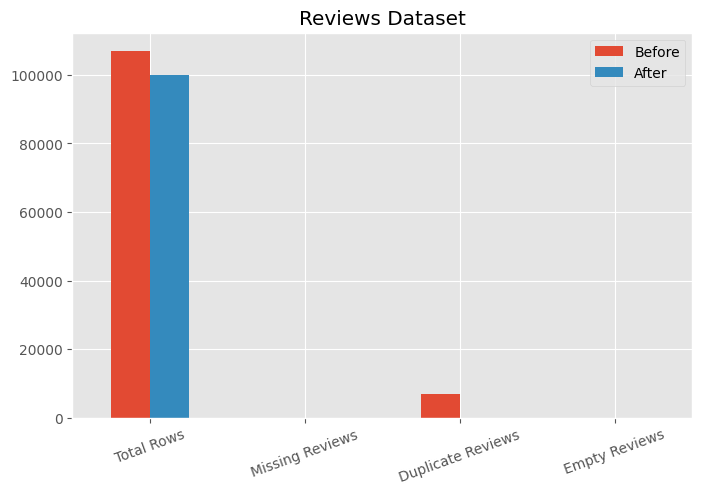

In [24]:
def compare(before,after,title):

    df=pd.DataFrame({
        "Before":before,
        "After":after
    })

    df.plot(kind="bar",figsize=(8,5))
    plt.title(title)
    plt.xticks(rotation=20)
    plt.show()

compare(reviews_before,reviews_after,"Reviews Dataset")


## Final Verification

In [25]:
print("="*60)
print("Reviews Dataset")
print(reviews_clean.shape)
display(reviews_clean.head())

print("\nModule 2 Completed Successfully.")

Reviews Dataset
(99850, 3)


,Id,Review,Label
0,0,good and interesting,2
1,1,"This class is very helpful to me. Currently, I...",2
2,2,like!Prof and TAs are helpful and the discussi...,2
3,3,Easy to follow and includes a lot basic and im...,2
4,4,Really nice teacher!I could got the point eazl...,2



Module 2 Completed Successfully.


---
# Module_3_DeBERTa


# Module 3: DeBERTa Training

Train and evaluate DeBERTa on cleaned dataset with validation, early stopping, and best-model saving.

In [26]:
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [27]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [28]:
reviews = pd.read_csv("reviews_cleaned.csv")

print(reviews.shape)
reviews.head()

(99850, 3)


,Id,Review,Label
0,0,good and interesting,2
1,1,"This class is very helpful to me. Currently, I...",2
2,2,like!Prof and TAs are helpful and the discussi...,2
3,3,Easy to follow and includes a lot basic and im...,2
4,4,Really nice teacher!I could got the point eazl...,2


In [29]:
print(reviews["Label"].value_counts())

print("\nUnique Labels:")
print(sorted(reviews["Label"].unique()))

Label
2    90276
1     4978
0     4596
Name: count, dtype: int64

Unique Labels:
[np.int64(0), np.int64(1), np.int64(2)]


In [30]:
train_df, test_df = train_test_split(
    reviews,
    test_size=0.20,
    stratify=reviews["Label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", train_df.shape)
print("Testing :", test_df.shape)

Training: (79880, 3)
Testing : (19970, 3)


In [31]:
MODEL_NAME = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

model.to(device)

print("Model Loaded Successfully!")

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  371MB            

...

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier

model.safetensors: reconstructing file:   0%|          |  0.00B /  371MB            

model.safetensors: downloading bytes:           |  0.00B            

Model Loaded Successfully!


In [32]:
for name, param in model.named_parameters():
    if torch.isnan(param).any():
        print("NaN Found:", name)
        break
else:
    print("✅ Model is clean.")

✅ Model is clean.


In [33]:
print(reviews.columns)

Index(['Id', 'Review', 'Label'], dtype='object')


In [34]:
class ReviewDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=256):
        self.texts = dataframe["Review"].tolist()
        self.labels = dataframe["Label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [38]:
BATCH_SIZE = 16

train_dataset = ReviewDataset(train_df, tokenizer)
test_dataset = ReviewDataset(test_df, tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))

Train batches: 4993
Test batches : 1249


In [39]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_df["Label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["Label"]
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32,
    device=device
)

print(class_weights.dtype)

torch.float32


In [40]:
EPOCHS = 4
LEARNING_RATE = 1e-5

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print("Total training steps:", total_steps)

Total training steps: 19972


In [41]:
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

print("Criterion weight dtype:", criterion.weight.dtype)

Criterion weight dtype: torch.float32


In [42]:
model = model.float().to(device)

print(model.dtype)

torch.float32


In [43]:
def train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=4,
    patience=2
):

    best_val_loss = float("inf")
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": []
    }

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-" * 50)

        ####################
        # TRAINING
        ####################
        model.train()

        train_loss = 0

        for batch in tqdm(train_loader):

            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(outputs.logits, labels)

            if torch.isnan(loss):
                raise RuntimeError("NaN loss detected.")

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()
            scheduler.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        ####################
        # VALIDATION
        ####################
        model.eval()

        val_loss = 0

        predictions = []
        actuals = []

        with torch.no_grad():

            for batch in test_loader:

                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                loss = criterion(outputs.logits, labels)

                val_loss += loss.item()

                preds = torch.argmax(
                    outputs.logits,
                    dim=1
                )

                predictions.extend(preds.cpu().numpy())
                actuals.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(test_loader)

        ####################
        # METRICS
        ####################
        accuracy = accuracy_score(
            actuals,
            predictions
        )

        precision = precision_score(
            actuals,
            predictions,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            actuals,
            predictions,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            actuals,
            predictions,
            average="weighted",
            zero_division=0
        )

        ####################
        # SAVE METRICS
        ####################
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(accuracy)
        history["val_precision"].append(precision)
        history["val_recall"].append(recall)
        history["val_f1"].append(f1)

        print(f"Train Loss : {avg_train_loss:.4f}")
        print(f"Val Loss   : {avg_val_loss:.4f}")
        print(f"Accuracy   : {accuracy:.4f}")
        print(f"Precision  : {precision:.4f}")
        print(f"Recall     : {recall:.4f}")
        print(f"F1 Score   : {f1:.4f}")

        ####################
        # EARLY STOPPING
        ####################
        if avg_val_loss < best_val_loss:

            best_val_loss = avg_val_loss
            patience_counter = 0

            torch.save(
                model.state_dict(),
                "best_deberta_model.pt"
            )

            tokenizer.save_pretrained(
                "best_deberta_tokenizer"
            )

            print("Best model saved.")

        else:

            patience_counter += 1

            if patience_counter >= patience:

                print("Early stopping.")
                break

    return history

In [44]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

model.eval()

with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

print("Model dtype      :", model.dtype)
print("Logits dtype     :", outputs.logits.dtype)
print("Labels dtype     :", labels.dtype)
print("Criterion weight :", criterion.weight.dtype)

Model dtype      : torch.float32
Logits dtype     : torch.float32
Labels dtype     : torch.int64
Criterion weight : torch.float32


In [45]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [46]:
history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=4,
    patience=2
)


Epoch 1/4
--------------------------------------------------


  0%|          | 0/4993 [00:00<?, ?it/s]

Train Loss : 0.7111
Val Loss   : 0.7947
Accuracy   : 0.9370
Precision  : 0.9341
Recall     : 0.9370
F1 Score   : 0.9352
Best model saved.

Epoch 2/4
--------------------------------------------------


  0%|          | 0/4993 [00:00<?, ?it/s]

Train Loss : 0.5834
Val Loss   : 0.6763
Accuracy   : 0.9281
Precision  : 0.9452
Recall     : 0.9281
F1 Score   : 0.9349
Best model saved.

Epoch 3/4
--------------------------------------------------


  0%|          | 0/4993 [00:00<?, ?it/s]

Train Loss : 0.5146
Val Loss   : 0.9125
Accuracy   : 0.9369
Precision  : 0.9400
Recall     : 0.9369
F1 Score   : 0.9383

Epoch 4/4
--------------------------------------------------


  0%|          | 0/4993 [00:00<?, ?it/s]

Train Loss : 0.4317
Val Loss   : 1.0285
Accuracy   : 0.9367
Precision  : 0.9397
Recall     : 0.9367
F1 Score   : 0.9381
Early stopping.


# LIME

In [47]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=48b8751be7cbc7e2a2272f3787c61ff0dcb6502dcc7b34f8ed50864cc06fa02d
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [48]:
import numpy as np
import torch
from lime.lime_text import LimeTextExplainer

In [49]:
class_names = [
    "Negative",
    "Neutral",
    "Positive"
]

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

In [51]:
def predict_proba(texts):

    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():

        outputs = model(**encoded)

        probabilities = torch.softmax(outputs.logits, dim=1)

    return probabilities.cpu().numpy()

In [52]:
explainer = LimeTextExplainer(
    class_names=class_names
)

In [53]:
review = input("Enter a review:\n")

Enter a review:
This course was very helpful. The teacher explained every topic clearly, and I learned many new skills. I would recommend this course to others.


In [54]:
probs = predict_proba([review])

predicted_class = np.argmax(probs)

print("Predicted Sentiment :", class_names[predicted_class])

print()

for i, name in enumerate(class_names):
    print(f"{name}: {probs[0][i]:.4f}")

Predicted Sentiment : Positive

Negative: 0.0000
Neutral: 0.0004
Positive: 0.9996


In [55]:
exp = explainer.explain_instance(
    review,
    predict_proba,
    num_features=10,
    num_samples=500,
    top_labels=1
)

In [56]:
print(exp.as_list(label=predicted_class))

[(np.str_('recommend'), 0.0012372039665379745), (np.str_('very'), 0.0011307648903070777), (np.str_('every'), 0.0010947524831446856), (np.str_('learned'), 0.0009964878174119457), (np.str_('I'), 0.0008510446627389051), (np.str_('This'), 0.0008451910898285278), (np.str_('explained'), 0.0007589037932667957), (np.str_('clearly'), 0.000710953334208644), (np.str_('others'), -0.0005851495375690729), (np.str_('topic'), -0.0003418966229245492)]


In [57]:
exp.show_in_notebook(text=True)

In [58]:
review = input("Enter a review:\n")

Enter a review:
I did not enjoy this course. The lessons were confusing, and the examples were not clear. I expected better content and support


In [59]:
probs = predict_proba([review])

predicted_class = np.argmax(probs)

print("Predicted Sentiment :", class_names[predicted_class])

print()

for i, name in enumerate(class_names):
    print(f"{name}: {probs[0][i]:.4f}")

Predicted Sentiment : Negative

Negative: 0.9990
Neutral: 0.0008
Positive: 0.0002


In [60]:
exp = explainer.explain_instance(
    review,
    predict_proba,
    num_features=10,
    num_samples=500,
    top_labels=1
)

In [61]:
print(exp.as_list(label=predicted_class))

[(np.str_('not'), 0.8729530730452325), (np.str_('expected'), 0.06854687097519255), (np.str_('lessons'), 0.04464146443794728), (np.str_('examples'), 0.03239120157641152), (np.str_('the'), 0.028929116566055436), (np.str_('were'), 0.02567708845608959), (np.str_('this'), 0.02526197033910527), (np.str_('better'), 0.02498811548316318), (np.str_('clear'), -0.018012590855529524), (np.str_('enjoy'), -0.017201413881682663)]


In [62]:
exp.show_in_notebook(text=True)